# LOAD

In [ ]:
import gdown
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from imblearn.over_sampling import SMOTE

file_id = "1jPztXleFRAYeTyipYOm5pK3NyVIQ1ZpT"
url = f"https://drive.google.com/uc?export=download&id={file_id}"

gdown.download(url, "flight_data_2024.csv", quiet=False, fuzzy=True)

Downloading...
From (original): https://drive.google.com/uc?id=1jPztXleFRAYeTyipYOm5pK3NyVIQ1ZpT
From (redirected): https://drive.google.com/uc?id=1jPztXleFRAYeTyipYOm5pK3NyVIQ1ZpT&confirm=t&uuid=8b5ceae1-e12a-4f53-8b83-bd6e70ff41a0
To: /content/flight_data_2024.csv
100%|██████████| 1.31G/1.31G [00:13<00:00, 94.3MB/s]


'flight_data_2024.csv'

In [ ]:
df = pd.read_csv("flight_data_2024.csv", low_memory=False)

In [ ]:
print("Dataset shape:", df.shape)

Dataset shape: (7079081, 35)


In [ ]:
(df["cancelled"] == 1).sum()

np.int64(96315)

In [ ]:
display(df.head())

,year,month,day_of_month,day_of_week,fl_date,op_unique_carrier,op_carrier_fl_num,origin,origin_city_name,origin_state_nm,...,diverted,crs_elapsed_time,actual_elapsed_time,air_time,distance,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
0,2024,1,1,1,2024-01-01,9E,4814.0,JFK,"New York, NY",New York,...,0,136.0,122.0,84.0,509.0,0,0,0,0,0
1,2024,1,1,1,2024-01-01,9E,4815.0,MSP,"Minneapolis, MN",Minnesota,...,0,130.0,114.0,88.0,622.0,0,0,0,0,0
2,2024,1,1,1,2024-01-01,9E,4817.0,JFK,"New York, NY",New York,...,0,106.0,90.0,61.0,288.0,0,0,0,0,0
3,2024,1,1,1,2024-01-01,9E,4817.0,RIC,"Richmond, VA",Virginia,...,0,111.0,76.0,51.0,288.0,0,0,0,0,0
4,2024,1,1,1,2024-01-01,9E,4818.0,DTW,"Detroit, MI",Michigan,...,0,79.0,70.0,45.0,237.0,0,0,0,0,0


In [ ]:
display(df.describe(include="all").transpose().head(10))

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
year,7079081.0,NaN,NaN,NaN,2024.0,0.0,2024.0,2024.0,2024.0,2024.0,2024.0
month,7079081.0,NaN,NaN,NaN,6.584868,3.396806,1.0,4.0,7.0,10.0,12.0
day_of_month,7079081.0,NaN,NaN,NaN,15.784451,8.786433,1.0,8.0,16.0,23.0,31.0
day_of_week,7079081.0,NaN,NaN,NaN,3.981945,2.012279,1.0,2.0,4.0,6.0,7.0
fl_date,7079081,366,2024-12-01,21764,NaN,NaN,NaN,NaN,NaN,NaN,NaN
op_unique_carrier,7079081,15,WN,1419419,NaN,NaN,NaN,NaN,NaN,NaN,NaN
op_carrier_fl_num,7079080.0,NaN,NaN,NaN,2504.622501,1652.252505,1.0,1151.0,2227.0,3717.0,8819.0
origin,7079081,348,ATL,341910,NaN,NaN,NaN,NaN,NaN,NaN,NaN
origin_city_name,7079081,342,"Chicago, IL",359685,NaN,NaN,NaN,NaN,NaN,NaN,NaN
origin_state_nm,7079081,52,Texas,751839,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7079081 entries, 0 to 7079080
Data columns (total 35 columns):
 #   Column               Dtype  
---  ------               -----  
 0   year                 int64  
 1   month                int64  
 2   day_of_month         int64  
 3   day_of_week          int64  
 4   fl_date              object 
 5   op_unique_carrier    object 
 6   op_carrier_fl_num    float64
 7   origin               object 
 8   origin_city_name     object 
 9   origin_state_nm      object 
 10  dest                 object 
 11  dest_city_name       object 
 12  dest_state_nm        object 
 13  crs_dep_time         int64  
 14  dep_time             float64
 15  dep_delay            float64
 16  taxi_out             float64
 17  wheels_off           float64
 18  wheels_on            float64
 19  taxi_in              float64
 20  crs_arr_time         int64  
 21  arr_time             float64
 22  arr_delay            float64
 23  cancelled            int64  
 24

In [ ]:
df.isnull().sum()

,0
year,0
month,0
day_of_month,0
day_of_week,0
fl_date,0
op_unique_carrier,0
op_carrier_fl_num,1
origin,0
origin_city_name,0
origin_state_nm,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df["dep_delay"].describe(percentiles=[0.25, 0.5, 0.75, 0.95, 0.99])

,dep_delay
count,6.986111e+06
mean,1.267708e+01
std,5.605997e+01
min,-9.600000e+01
25%,-6.000000e+00
50%,-2.000000e+00
75%,9.000000e+00
95%,8.400000e+01
99%,2.160000e+02
max,3.777000e+03


# TRANSFORM

In [ ]:
df.columns = df.columns.str.strip().str.lower()

In [ ]:
# Cek dulu apakah ada anomali
jumlah_distance_aneh = (df["distance"] <= 0).sum()
jumlah_durasi_aneh = (df["crs_elapsed_time"] <= 0).sum()

print("Jumlah distance <= 0:", jumlah_distance_aneh)
print("Jumlah crs_elapsed_time <= 0:", jumlah_durasi_aneh)

display(df[(df["distance"] <= 0) | (df["crs_elapsed_time"] <= 0)])

Jumlah distance <= 0: 0
Jumlah crs_elapsed_time <= 0: 1


,year,month,day_of_month,day_of_week,fl_date,op_unique_carrier,op_carrier_fl_num,origin,origin_city_name,origin_state_nm,...,diverted,crs_elapsed_time,actual_elapsed_time,air_time,distance,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
1577980,2024,3,27,3,2024-03-27,WN,336.0,LAS,"Las Vegas, NV",Nevada,...,0,-160.0,NaN,NaN,345.0,0,0,0,0,0


In [ ]:
df["fl_date"] = pd.to_datetime(df["fl_date"], errors="coerce")

In [ ]:
df["cancelled"] = df["cancelled"].fillna(0).astype(int)
df["diverted"] = df["diverted"].fillna(0).astype(int)

In [ ]:
delay_cols = [
    "carrier_delay",
    "weather_delay",
    "nas_delay",
    "security_delay",
    "late_aircraft_delay",
]

for col in delay_cols:
    df[col] = df[col].fillna(0)

In [ ]:
# Format asli HHMM (misal 1730 = jam 17:30) diubah jadi total menit
# supaya jarak antar waktu lebih akurat secara numerik
df["crs_dep_time_minutes"] = (df["crs_dep_time"] // 100) * 60 + (df["crs_dep_time"] % 100)
df["crs_arr_time_minutes"] = (df["crs_arr_time"] // 100) * 60 + (df["crs_arr_time"] % 100)

df[["crs_dep_time", "crs_dep_time_minutes", "crs_arr_time", "crs_arr_time_minutes"]].head()

,crs_dep_time,crs_dep_time_minutes,crs_arr_time,crs_arr_time_minutes
0,1252,772,1508,908
1,1015,615,1325,805
2,1415,855,1601,961
3,1650,1010,1841,1121
4,1015,615,1034,634


In [ ]:
df.loc[df["dep_delay"].isna() & (df["cancelled"] == 0), "dep_delay"] = 0
df.loc[df["dep_delay"].isna() & (df["cancelled"] == 1), "dep_delay"] = 1741

In [ ]:
df["dep_delay"]

,dep_delay
0,-5.0
1,-14.0
2,-4.0
3,-7.0
4,-5.0
...,...
7079076,-6.0
7079077,-11.0
7079078,-7.0
7079079,-6.0


In [ ]:
df["cancelled"].value_counts()

,count
cancelled,
0,6982766
1,96315


In [ ]:
df_delay_lebih = df[df["dep_delay"] > 1740].reset_index(drop=True)
df = df[df["dep_delay"] <= 1740].reset_index(drop=True)

df_delay_lebih.to_csv("dep_delay_lebih_1740.csv", index=False)

In [ ]:
df["cancelled"].value_counts()

,count
cancelled,
0,6982570
1,3343


In [ ]:
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6985913 entries, 0 to 6985912
Data columns (total 37 columns):
 #   Column                Dtype         
---  ------                -----         
 0   year                  int64         
 1   month                 int64         
 2   day_of_month          int64         
 3   day_of_week           int64         
 4   fl_date               datetime64[ns]
 5   op_unique_carrier     object        
 6   op_carrier_fl_num     float64       
 7   origin                object        
 8   origin_city_name      object        
 9   origin_state_nm       object        
 10  dest                  object        
 11  dest_city_name        object        
 12  dest_state_nm         object        
 13  crs_dep_time          int64         
 14  dep_time              float64       
 15  dep_delay             float64       
 16  taxi_out              float64       
 17  wheels_off            float64       
 18  wheels_on             float64       
 19  

,year,month,day_of_month,day_of_week,fl_date,op_unique_carrier,op_carrier_fl_num,origin,origin_city_name,origin_state_nm,...,actual_elapsed_time,air_time,distance,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay,crs_dep_time_minutes,crs_arr_time_minutes
0,2024,1,1,1,2024-01-01,9E,4814.0,JFK,"New York, NY",New York,...,122.0,84.0,509.0,0,0,0,0,0,772,908
1,2024,1,1,1,2024-01-01,9E,4815.0,MSP,"Minneapolis, MN",Minnesota,...,114.0,88.0,622.0,0,0,0,0,0,615,805
2,2024,1,1,1,2024-01-01,9E,4817.0,JFK,"New York, NY",New York,...,90.0,61.0,288.0,0,0,0,0,0,855,961
3,2024,1,1,1,2024-01-01,9E,4817.0,RIC,"Richmond, VA",Virginia,...,76.0,51.0,288.0,0,0,0,0,0,1010,1121
4,2024,1,1,1,2024-01-01,9E,4818.0,DTW,"Detroit, MI",Michigan,...,70.0,45.0,237.0,0,0,0,0,0,615,634


In [ ]:
df["is_delayed"] = (df["dep_delay"] > 15).astype(int)

# VALUE

In [ ]:
print("Jumlah unique op_unique_carrier:", df["op_unique_carrier"].nunique())
print("Jumlah unique origin:", df["origin"].nunique())
print("Jumlah unique dest:", df["dest"].nunique())

Jumlah unique op_unique_carrier: 15
Jumlah unique origin: 348
Jumlah unique dest: 348


In [ ]:
# Lihat distribusi delay secara umum
df["dep_delay"].describe()
df["arr_delay"].describe()

,arr_delay
count,6.965073e+06
mean,7.038068e+00
std,5.681954e+01
min,-1.260000e+02
25%,-1.500000e+01
50%,-6.000000e+00
75%,9.000000e+00
max,1.789000e+03


In [ ]:
#Total Flight Delay (>15 Menit)

df["is_delayed"].value_counts()

,count
is_delayed,
0,5589027
1,1396886


In [ ]:
print("Persentase is_delayed per maskapai:")
print(df.groupby("op_unique_carrier")["is_delayed"].mean().sort_values(ascending=False))

print("\nPersentase is_delayed per bandara asal (top 10):")
print(df.groupby("origin")["is_delayed"].mean().sort_values(ascending=False).head(10))

Persentase is_delayed per maskapai:
op_unique_carrier
F9    0.270484
B6    0.251514
AA    0.249232
NK    0.242734
WN    0.224066
G4    0.205912
AS    0.193452
OH    0.192735
UA    0.184631
MQ    0.181701
OO    0.167033
DL    0.165911
9E    0.145091
HA    0.125153
YX    0.114213
Name: is_delayed, dtype: float64

Persentase is_delayed per bandara asal (top 10):
origin
HTS    0.427184
MGW    0.405405
EWN    0.404255
SPI    0.361905
HGR    0.355401
SCK    0.335283
OTH    0.334311
CKB    0.331683
IAG    0.314667
SMX    0.311321
Name: is_delayed, dtype: float64


In [ ]:
# maskapai dengan rata-rata dep delay tertinggi
df.groupby("op_unique_carrier")["dep_delay"] \
  .mean() \
  .sort_values(ascending=False) \
  .head(10)

,dep_delay
op_unique_carrier,
AA,20.313810
F9,19.002299
B6,17.431321
NK,14.957090
G4,14.047917
OH,13.800705
UA,11.954279
WN,11.748603
OO,11.272481


In [ ]:
# Lihat total penyebab delay
delay_cols = [
    "carrier_delay",
    "weather_delay",
    "nas_delay",
    "security_delay",
    "late_aircraft_delay"
]

df[delay_cols].sum().sort_values(ascending=False)

,0
late_aircraft_delay,41872286
carrier_delay,35518084
nas_delay,19615767
weather_delay,6188482
security_delay,179928


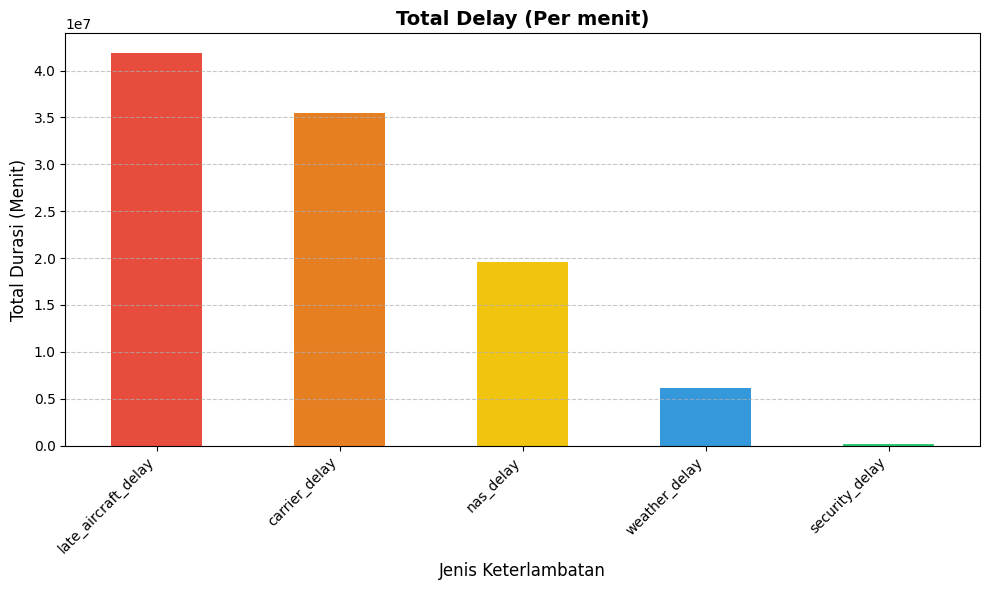

In [ ]:
import matplotlib.pyplot as plt

# 1. Menghitung total penyebab delay dan mengurutkannya
delay_cols = [
    "carrier_delay",
    "weather_delay",
    "nas_delay",
    "security_delay",
    "late_aircraft_delay"
]

total_delays = df[delay_cols].sum().sort_values(ascending=False)

# 2. Membuat plot grafik
plt.figure(figsize=(10, 6)) # Mengatur ukuran grafik
total_delays.plot(kind='bar', color=['#e74c3c', '#e67e22', '#f1c40f', '#3498db', '#2ecc71'])

# 3. Menambahkan elemen visual (Judul, Label, dll)
plt.title('Total Delay (Per menit)', fontsize=14, fontweight='bold')
plt.xlabel('Jenis Keterlambatan', fontsize=12)
plt.ylabel('Total Durasi (Menit)', fontsize=12)

# Memiringkan teks di sumbu X agar tidak saling tumpang tindih
plt.xticks(rotation=45, ha='right')

# Menambahkan garis bantu horizontal
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 4. Menyesuaikan layout dan menampilkan grafik
plt.tight_layout()
plt.show()

In [ ]:
# Lihat rata-rata dep delay per bulan
df.groupby("month")["dep_delay"].mean()

,dep_delay
month,
1,15.607250
2,7.409866
3,12.373413
4,10.739165
5,18.039337
6,16.891451
7,22.267604
8,15.267611
9,6.588795


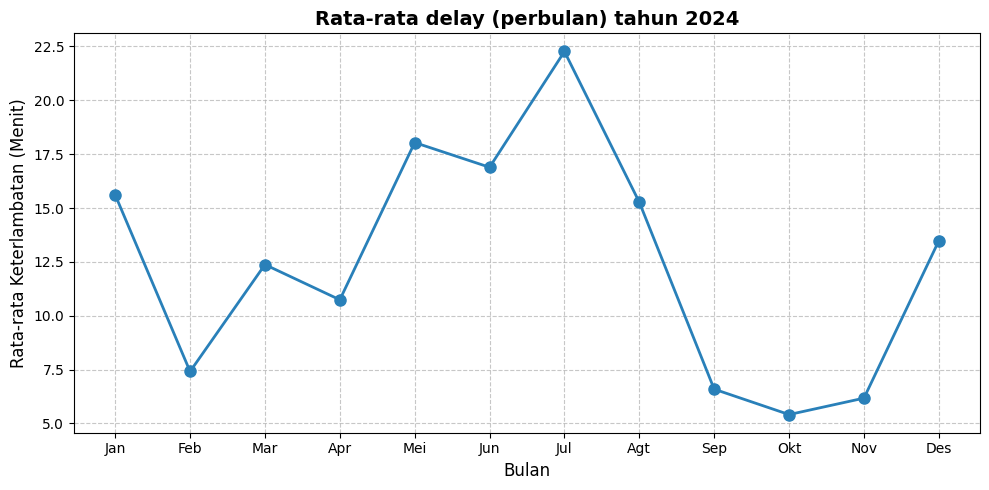

In [ ]:
import matplotlib.pyplot as plt

# 1. Menghitung rata-rata delay per bulan
avg_delay_per_month = df.groupby("month")["dep_delay"].mean()

# 2. Membuat plot grafik garis
plt.figure(figsize=(10, 5)) # Mengatur ukuran grafik
avg_delay_per_month.plot(kind='line', marker='o', color='#2980b9', linewidth=2, markersize=8)

# 3. Menambahkan elemen visual (Judul, Label, dll)
plt.title('Rata-rata delay (perbulan) tahun 2024', fontsize=14, fontweight='bold')
plt.xlabel('Bulan', fontsize=12)
plt.ylabel('Rata-rata Keterlambatan (Menit)', fontsize=12)

# Mengubah angka bulan (1-12) menjadi nama bulan agar lebih mudah dibaca
bulan_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'Mei', 'Jun', 'Jul', 'Agt', 'Sep', 'Okt', 'Nov', 'Des']
plt.xticks(range(1, 13), bulan_labels)

# Menambahkan garis bantu (grid) agar nilai mudah dibaca
plt.grid(True, linestyle='--', alpha=0.7)

# 4. Menyesuaikan layout dan menampilkan grafik
plt.tight_layout()
plt.show()

In [ ]:
# Flight dengan departure delay paling tinggi
df.sort_values("dep_delay", ascending=False)[[
    "fl_date",
    "op_unique_carrier",
    "op_carrier_fl_num",
    "origin",
    "dest",
    "dep_delay"
]].head(10)

,fl_date,op_unique_carrier,op_carrier_fl_num,origin,dest,dep_delay
241495,2024-01-15,AA,1356.0,BNA,DFW,1739.0
5541633,2024-10-17,OH,5176.0,DTW,PHL,1739.0
4877785,2024-09-13,OH,5188.0,RDU,PHL,1739.0
128492,2024-01-08,AA,629.0,STL,ORD,1738.0
4877939,2024-09-13,OH,5330.0,SDF,PHL,1734.0
6840603,2024-12-24,AA,2674.0,TUL,DFW,1733.0
2327558,2024-05-07,AA,2150.0,SJU,CLT,1732.0
257244,2024-01-16,AA,1501.0,BZN,ORD,1730.0
726922,2024-02-12,HA,81.0,AUS,HNL,1729.0
2773344,2024-05-30,AA,814.0,AUS,DFW,1728.0


In [ ]:
# Rute dengan rata-rata arrival delay tertinggi
df.groupby(["origin", "dest"])["arr_delay"] \
  .mean() \
  .sort_values(ascending=False) \
  .head(10)

,,arr_delay
origin,dest,
JFK,LGA,755.000000
SDF,SLC,365.000000
IAD,MSN,325.000000
AVL,USA,310.000000
SRQ,IAH,299.600000
IAH,SDF,194.000000
MVY,CLT,190.090909
PIE,VPS,178.000000
OKC,CAE,171.000000


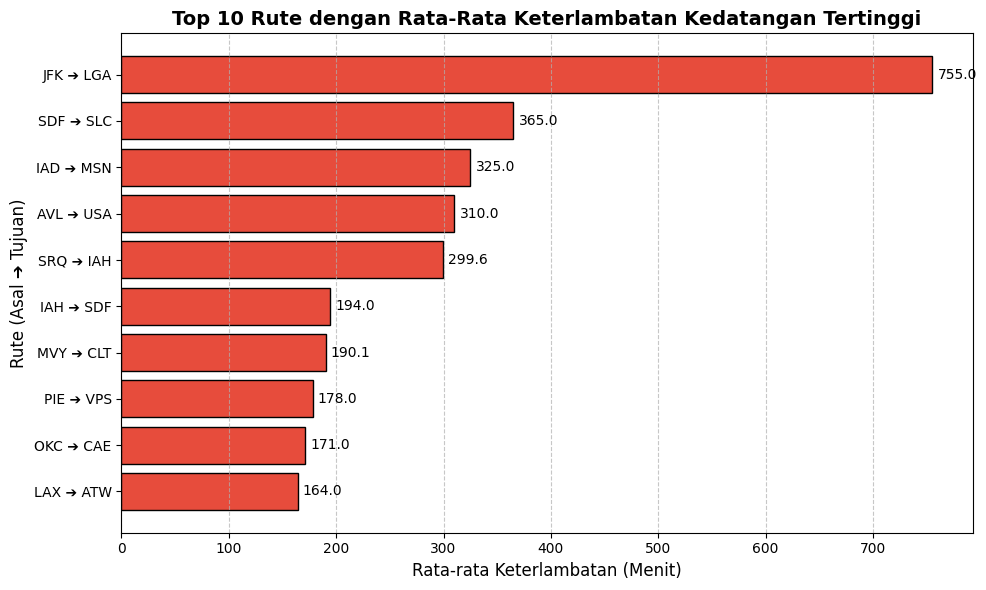

In [ ]:
import matplotlib.pyplot as plt

# 1. Menghitung top 10 rute dengan rata-rata arr_delay tertinggi
top_routes_delay = df.groupby(["origin", "dest"])["arr_delay"].mean().sort_values(ascending=False).head(10)

# 2. Menggabungkan nama Origin dan Dest agar lebih rapi untuk label grafik (contoh: "JFK - LGA")
# Index saat ini adalah MultiIndex (origin, dest), kita gabungkan menjadi string
route_labels = [f"{orig} ➔ {dest}" for orig, dest in top_routes_delay.index]

# 3. Membuat plot grafik batang horizontal
plt.figure(figsize=(10, 6))

# Kita membalik urutan (menggunakan [::-1]) agar ranking 1 berada di posisi paling atas grafik
bars = plt.barh(route_labels[::-1], top_routes_delay.values[::-1], color='#e74c3c', edgecolor='black')

# 4. Menambahkan elemen visual (Judul, Label, dll)
plt.title('Top 10 Rute dengan Rata-Rata Keterlambatan Kedatangan Tertinggi', fontsize=14, fontweight='bold')
plt.xlabel('Rata-rata Keterlambatan (Menit)', fontsize=12)
plt.ylabel('Rute (Asal ➔ Tujuan)', fontsize=12)

# Menambahkan angka (label) persis di sebelah setiap batang grafik
for bar in bars:
    plt.text(bar.get_width() + 5,  # Posisi X (sedikit di kanan ujung batang)
             bar.get_y() + bar.get_height()/2, # Posisi Y (di tengah batang)
             f'{bar.get_width():.1f}', # Format angka 1 desimal
             va='center', fontsize=10)

# Menambahkan garis bantu vertikal
plt.grid(axis='x', linestyle='--', alpha=0.7)

# 5. Menyesuaikan layout dan menampilkan grafik
plt.tight_layout()
plt.show()

In [ ]:
# Hari dalam seminggu dengan rata-rata delay tertinggi
df.groupby("day_of_week")["arr_delay"] \
  .mean() \
  .sort_values(ascending=False)

,arr_delay
day_of_week,
5,9.545012
7,8.719525
4,8.125246
1,6.944537
6,6.378354
3,4.769528
2,4.355409


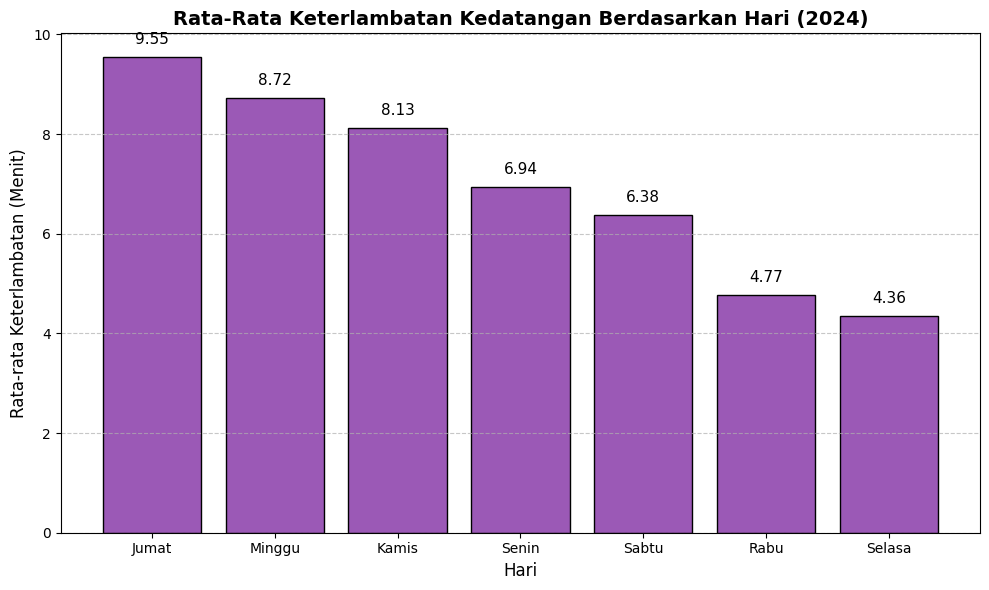

In [ ]:
import matplotlib.pyplot as plt

# 1. Menghitung rata-rata delay kedatangan per hari dan mengurutkannya
avg_delay_per_day = df.groupby("day_of_week")["arr_delay"].mean().sort_values(ascending=False)

# 2. Mengubah angka hari (1-7) menjadi nama hari agar informatif
# Asumsi standar penerbangan: 1 = Senin, 2 = Selasa, ..., 7 = Minggu
day_mapping = {
    1: 'Senin', 2: 'Selasa', 3: 'Rabu',
    4: 'Kamis', 5: 'Jumat', 6: 'Sabtu', 7: 'Minggu'
}
# Ganti index angka menjadi nama hari
avg_delay_per_day.index = avg_delay_per_day.index.map(day_mapping)

# 3. Membuat plot grafik batang vertikal
plt.figure(figsize=(10, 6))
bars = plt.bar(avg_delay_per_day.index, avg_delay_per_day.values, color='#9b59b6', edgecolor='black')

# 4. Menambahkan elemen visual (Judul, Label, dll)
plt.title('Rata-Rata Keterlambatan Kedatangan Berdasarkan Hari (2024)', fontsize=14, fontweight='bold')
plt.xlabel('Hari', fontsize=12)
plt.ylabel('Rata-rata Keterlambatan (Menit)', fontsize=12)

# Menambahkan teks angka di atas masing-masing batang
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2,  # Posisi X (di tengah batang)
             bar.get_height() + 0.2,           # Posisi Y (sedikit di atas batang)
             f'{bar.get_height():.2f}',        # Format angka 2 desimal
             ha='center', va='bottom', fontsize=11)

# Menambahkan garis bantu horizontal
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 5. Menyesuaikan layout dan menampilkan grafik
plt.tight_layout()
plt.show()

In [ ]:
# Bulan dengan jumlah flight delay terbanyak
df["is_delayed"] = (df["dep_delay"] > 15).astype(int)

df.groupby("month")["is_delayed"] \
  .sum() \
  .sort_values(ascending=False)

,is_delayed
month,
7,177175
5,150070
6,148350
8,135947
12,122772
1,118500
3,118331
4,105640
9,84085


,total_cancelled
origin,
DFW,5837.0
LGA,3846.0
ORD,3785.0
DEN,3485.0
ATL,3410.0
EWR,3250.0
CLT,2977.0
MCO,2910.0
IAH,2354.0


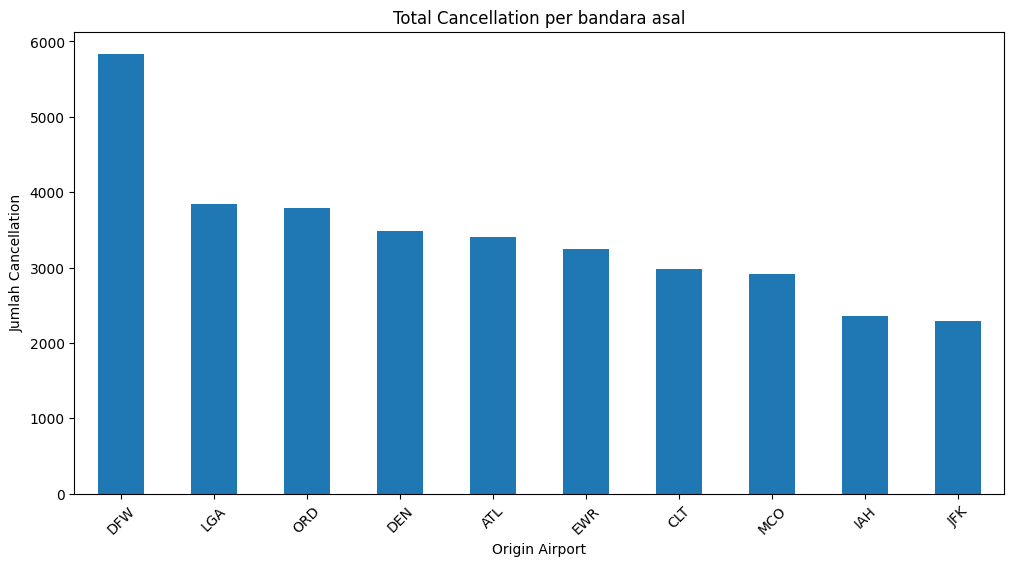

In [ ]:
# perbandingan data airport asal dengan jumlah cancellation terbanyak

cancel_main = df.groupby("origin")["cancelled"].sum()
cancel_extreme = df_delay_lebih.groupby("origin")["cancelled"].sum()

cancel_total = cancel_main.add(cancel_extreme, fill_value=0) \
    .sort_values(ascending=False) \
    .head(10)

display(cancel_total.to_frame(name="total_cancelled"))

cancel_total.plot(kind="bar", figsize=(12, 6))
plt.title("Total Cancellation per bandara asal")
plt.xlabel("Origin Airport")
plt.ylabel("Jumlah Cancellation")
plt.xticks(rotation=45)
plt.show()

,total_cancelled
op_unique_carrier,
AA,15252
UA,12478
WN,11772
DL,9147
OO,8527
YX,5576
NK,4998
F9,4835
AS,4811


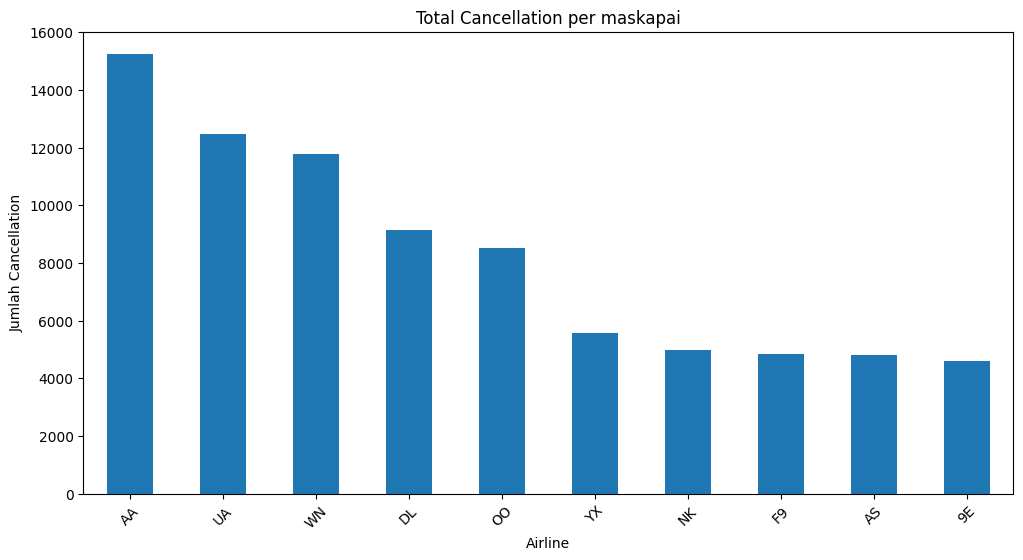

In [ ]:
# perbandingan maskapai dengan jumlah cancellation terbanyak
cancel_airline_main = df.groupby("op_unique_carrier")["cancelled"].sum()
cancel_airline_extreme = df_delay_lebih.groupby("op_unique_carrier")["cancelled"].sum()

cancel_airline_total = cancel_airline_main.add(cancel_airline_extreme, fill_value=0) \
    .sort_values(ascending=False) \
    .head(10)

display(cancel_airline_total.to_frame(name="total_cancelled"))

cancel_airline_total.plot(kind="bar", figsize=(12, 6))
plt.title("Total Cancellation per maskapai")
plt.xlabel("Airline")
plt.ylabel("Jumlah Cancellation")
plt.xticks(rotation=45)
plt.show()

In [ ]:
# Flight dengan departure delay paling tinggi
df_delay_lebih.sort_values("dep_delay", ascending=False)[[
    "fl_date",
    "op_unique_carrier",
    "op_carrier_fl_num",
    "origin",
    "dest",
    "dep_delay"
]].head(10)

,fl_date,op_unique_carrier,op_carrier_fl_num,origin,dest,dep_delay
47518,2024-07-05,AA,964.0,AUS,MIA,3777.0
26432,2024-03-18,AA,381.0,SEA,CLT,3360.0
29365,2024-04-08,AA,2613.0,SAN,PHX,3348.0
92274,2024-12-27,AA,2158.0,SMF,ORD,3274.0
90565,2024-12-19,AA,1561.0,GRR,DFW,3250.0
77368,2024-09-07,AA,2069.0,CMH,CLT,3130.0
1133,2024-01-08,AA,1865.0,IAH,DFW,3125.0
30997,2024-04-21,AA,2496.0,PDX,DFW,3024.0
31179,2024-04-25,AA,1908.0,LAS,DFW,3006.0
43701,2024-06-16,AA,234.0,SFO,JFK,2983.0


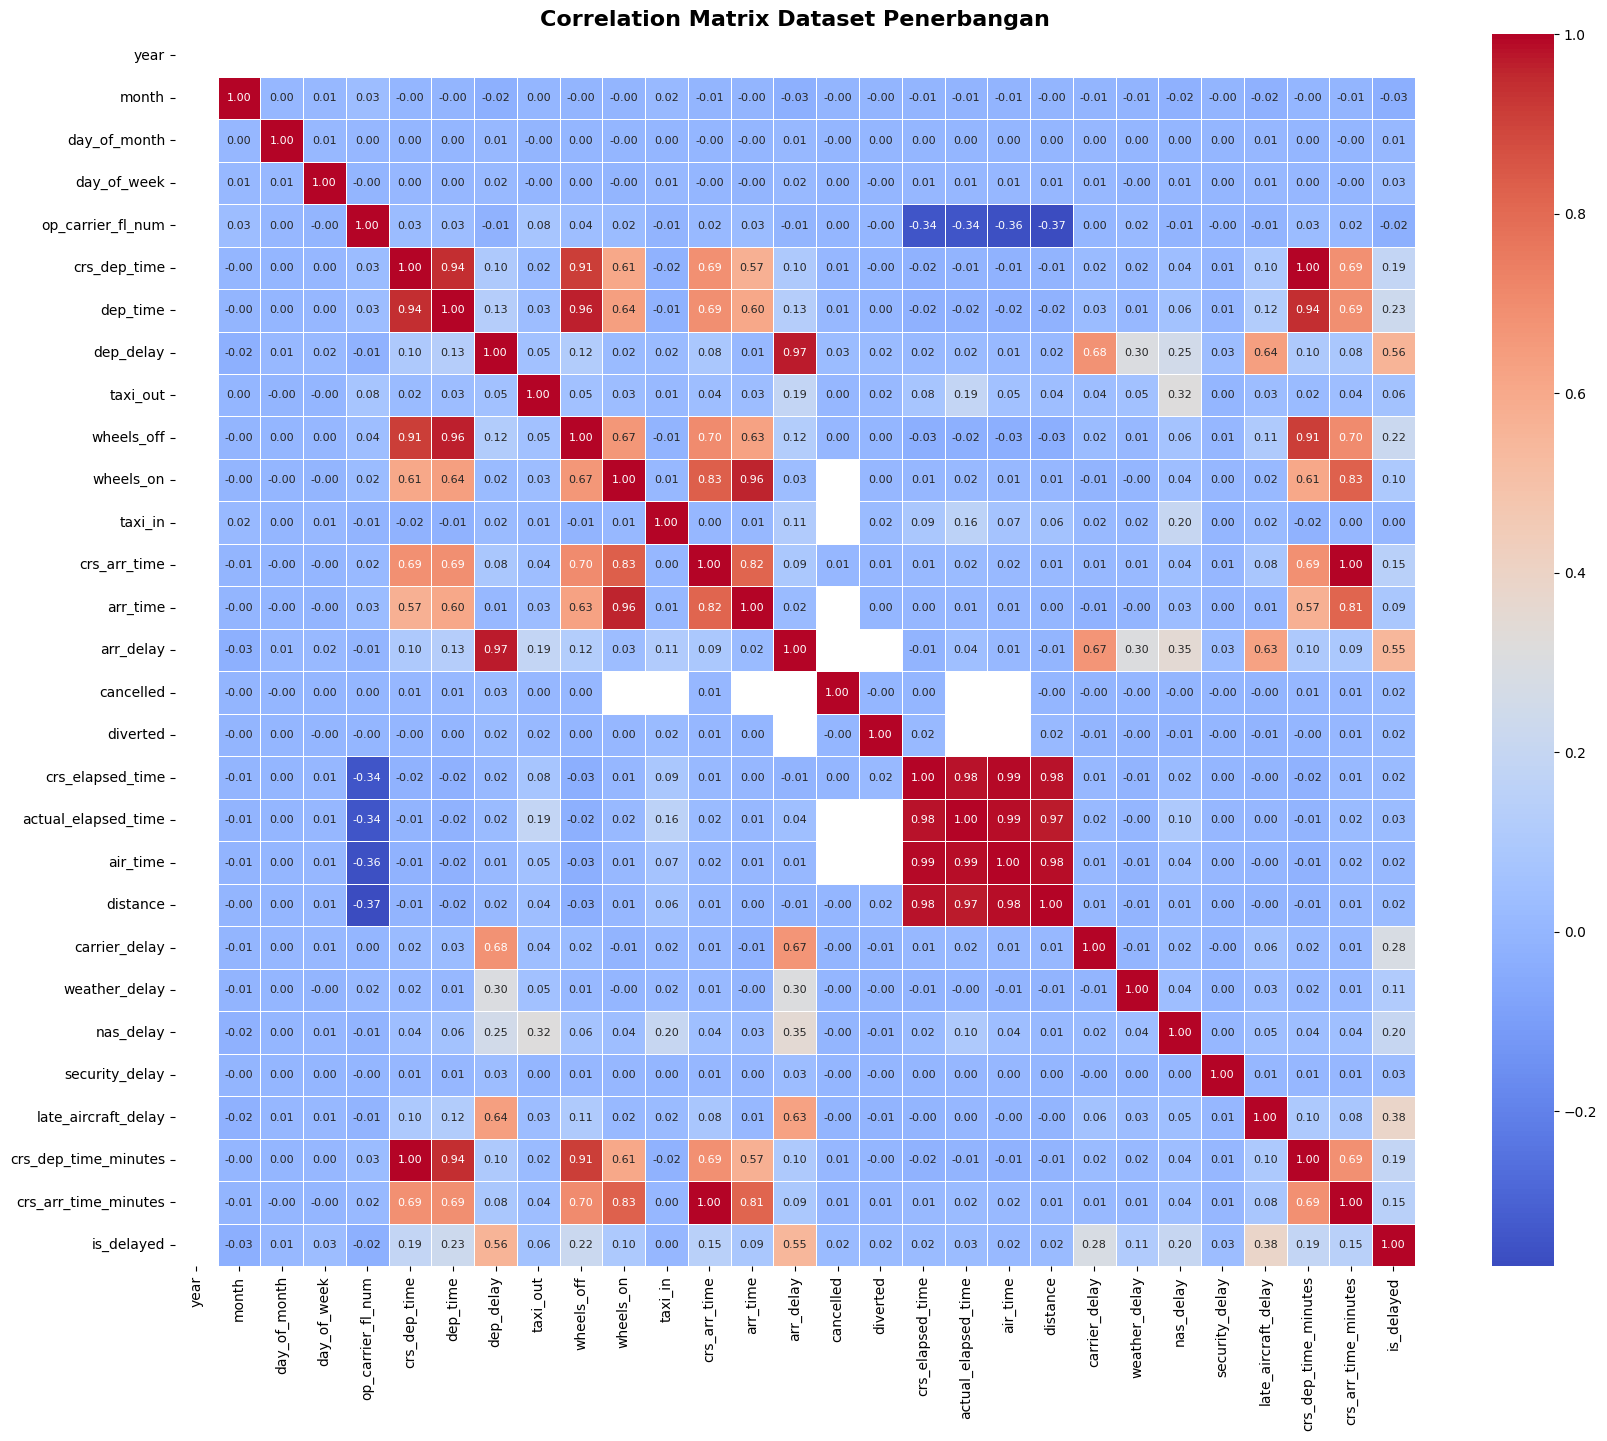

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Menghitung correlation matrix (hanya untuk kolom numerik)
corr_matrix = df.select_dtypes(include=['number']).corr()

# 2. Membuat visualisasi Heatmap
plt.figure(figsize=(20, 16)) # Ukuran gambar sedikit diperbesar agar lebih lega
sns.heatmap(corr_matrix,
            annot=True,            # Menampilkan angka di dalam kotak
            fmt=".2f",             # Memformat angka menjadi 2 desimal (misal: 0.85 atau -0.12)
            cmap='coolwarm',
            linewidths=0.5,
            annot_kws={"size": 8}) # Memperkecil ukuran font angka di dalam kotak menjadi 8

plt.title('Correlation Matrix Dataset Penerbangan', fontsize=16, fontweight='bold')
plt.show()

# PERSIAPAN DATA UNTUK MODELLING

In [ ]:
# ============================================================
# MODELING — Step 1: Siapkan Data
# ============================================================
import gc

FEATURES = [
    "month", "day_of_month", "day_of_week",
    "op_unique_carrier", "origin", "dest",
    "crs_dep_time_minutes", "crs_arr_time_minutes",
    "crs_elapsed_time", "distance"
]
TARGET = "is_delayed"

df_model = df[(df["cancelled"] == 0) & (df["diverted"] == 0)].copy()
df_model = df_model[FEATURES + [TARGET]].dropna().reset_index(drop=True)

print(f"Total baris untuk modeling : {len(df_model):,}")
print(f"Distribusi target:\n{df_model[TARGET].value_counts()}")
print(f"Proporsi delay             : {df_model[TARGET].mean():.3f}")

Total baris untuk modeling : 6,965,073
Distribusi target:
is_delayed
0    5576381
1    1388692
Name: count, dtype: int64
Proporsi delay             : 0.199


In [ ]:
# ============================================================
# MODELING — Step 2: Label Encoding
# ============================================================
from sklearn.preprocessing import LabelEncoder

CAT_COLS = ["op_unique_carrier", "origin", "dest"]

encoders = {}
for col in CAT_COLS:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col].astype(str))
    encoders[col] = le
    print(f"  {col}: {len(le.classes_)} kategori unik")

X = df_model[FEATURES].values
y = df_model[TARGET].values

# Bebaskan df_model dari RAM setelah X dan y sudah diambil
del df_model
gc.collect()

print(f"\nShape X: {X.shape}")
print(f"Shape y: {y.shape}")

  op_unique_carrier: 15 kategori unik
  origin: 348 kategori unik
  dest: 348 kategori unik

Shape X: (6965073, 10)
Shape y: (6965073,)


In [ ]:
print(df[TARGET].value_counts())
print()
print(df[TARGET].value_counts(normalize=True).mul(100).round(2).astype(str) + "%")

is_delayed
0    5589027
1    1396886
Name: count, dtype: int64

is_delayed
0    80.0%
1    20.0%
Name: proportion, dtype: object


# MODELLING

In [ ]:
# ============================================================
# MODELING — Step 3: StratifiedKFold + RandomForest
# ============================================================
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import gc

N_SPLITS = 5
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

fold_reports = []
fold_cms     = []

best_f1    = -1
best_model = None
best_fold  = -1

print(f"Mulai training {N_SPLITS}-Fold Cross Validation...\n")

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), start=1):
    print(f"=== Fold {fold}/{N_SPLITS} ===")

    X_train_fold = X[train_idx]
    X_val_fold   = X[val_idx]
    y_train_fold = y[train_idx]
    y_val_fold   = y[val_idx]

    print(f"  class 0: {(y_train_fold==0).sum():,} | class 1: {(y_train_fold==1).sum():,}")

    # class_weight='balanced' menggantikan SMOTE
    rf = RandomForestClassifier(
        n_estimators=100,
        max_depth=15,
        min_samples_leaf=10,
        class_weight='balanced',
        n_jobs=-1,
        random_state=42
    )
    rf.fit(X_train_fold, y_train_fold)
    del X_train_fold, y_train_fold
    gc.collect()

    # Evaluasi
    y_pred = rf.predict(X_val_fold)
    report = classification_report(y_val_fold, y_pred, output_dict=True)
    cm     = confusion_matrix(y_val_fold, y_pred)

    fold_reports.append(report)
    fold_cms.append(cm)

    fold_f1 = report["1"]["f1-score"]
    print(f"  Accuracy     : {report['accuracy']:.4f}")
    print(f"  F1 (delay=1) : {fold_f1:.4f}")

    if fold_f1 > best_f1:
        best_f1    = fold_f1
        best_model = rf
        best_fold  = fold
        print(f"  ✓ Model terbaik baru (fold {fold})")
    else:
        del rf
    gc.collect()
    print()

print(f"Training selesai. Model terbaik: Fold {best_fold} (F1={best_f1:.4f})")

Mulai training 5-Fold Cross Validation...

=== Fold 1/5 ===
  class 0: 4,461,104 | class 1: 1,110,954
  Accuracy     : 0.6655
  F1 (delay=1) : 0.4361
  ✓ Model terbaik baru (fold 1)

=== Fold 2/5 ===
  class 0: 4,461,105 | class 1: 1,110,953
  Accuracy     : 0.6656
  F1 (delay=1) : 0.4355

=== Fold 3/5 ===
  class 0: 4,461,105 | class 1: 1,110,953
  Accuracy     : 0.6664
  F1 (delay=1) : 0.4363
  ✓ Model terbaik baru (fold 3)

=== Fold 4/5 ===
  class 0: 4,461,105 | class 1: 1,110,954
  Accuracy     : 0.6644
  F1 (delay=1) : 0.4359

=== Fold 5/5 ===
  class 0: 4,461,105 | class 1: 1,110,954
  Accuracy     : 0.6646
  F1 (delay=1) : 0.4355

Training selesai. Model terbaik: Fold 3 (F1=0.4363)


=== Ringkasan Tiap Fold ===
 Fold  Accuracy  Precision (delay)  Recall (delay)  F1 (delay)
    1    0.6655             0.3285          0.6487      0.4361
    2    0.6656             0.3282          0.6471      0.4355
    3    0.6664             0.3290          0.6475      0.4363
    4    0.6644             0.3278          0.6502      0.4359
    5    0.6646             0.3277          0.6490      0.4355

Rata-rata Accuracy    : 0.6653 ± 0.0008
Rata-rata F1 (delay)  : 0.4359 ± 0.0004


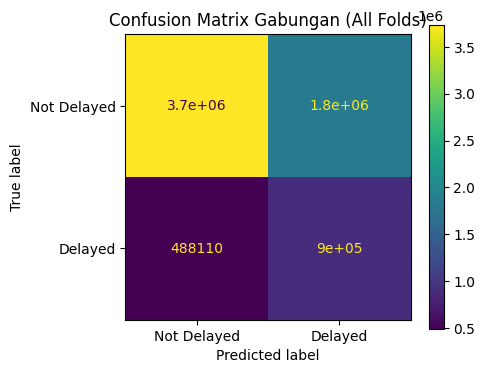

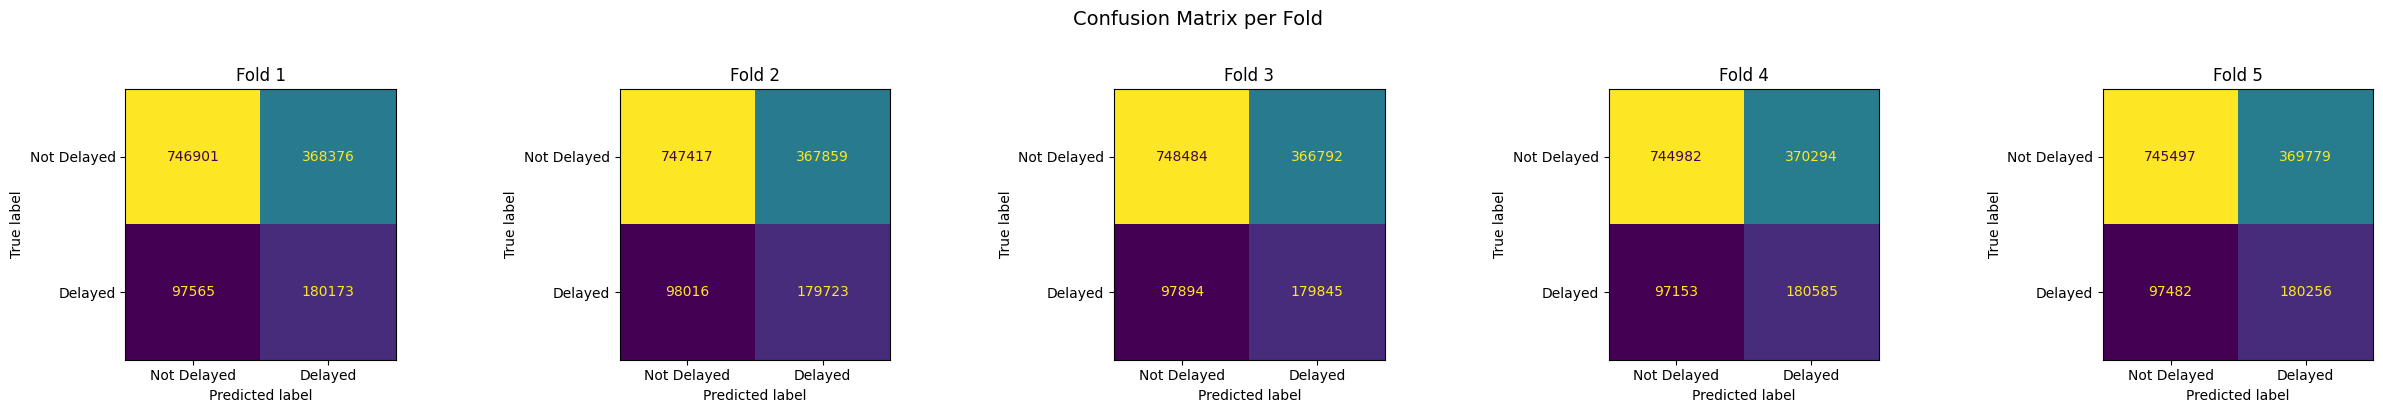

In [ ]:
# ============================================================
# MODELING — Step 4: Evaluasi Gabungan
# ============================================================
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

metrics_summary = []
for i, rep in enumerate(fold_reports, start=1):
    metrics_summary.append({
        "Fold"              : i,
        "Accuracy"          : round(rep["accuracy"], 4),
        "Precision (delay)" : round(rep["1"]["precision"], 4),
        "Recall (delay)"    : round(rep["1"]["recall"], 4),
        "F1 (delay)"        : round(rep["1"]["f1-score"], 4),
    })

df_summary = pd.DataFrame(metrics_summary)
print("=== Ringkasan Tiap Fold ===")
print(df_summary.to_string(index=False))
print()
print(f"Rata-rata Accuracy    : {df_summary['Accuracy'].mean():.4f} ± {df_summary['Accuracy'].std():.4f}")
print(f"Rata-rata F1 (delay)  : {df_summary['F1 (delay)'].mean():.4f} ± {df_summary['F1 (delay)'].std():.4f}")

# Plot confusion matrix gabungan
cm_total = sum(fold_cms)
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(confusion_matrix=cm_total,
                       display_labels=["Not Delayed", "Delayed"]).plot(ax=ax)
ax.set_title("Confusion Matrix Gabungan (All Folds)")
plt.tight_layout()
plt.show()

# Plot per fold
fig, axes = plt.subplots(1, N_SPLITS, figsize=(5 * N_SPLITS, 4))
for i, (cm, ax) in enumerate(zip(fold_cms, axes), start=1):
    ConfusionMatrixDisplay(confusion_matrix=cm,
                           display_labels=["Not Delayed", "Delayed"]).plot(ax=ax, colorbar=False)
    ax.set_title(f"Fold {i}")
plt.suptitle("Confusion Matrix per Fold", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

Training model final dengan seluruh data...
class 0: 5,576,381 | class 1: 1,388,692
Model final selesai.


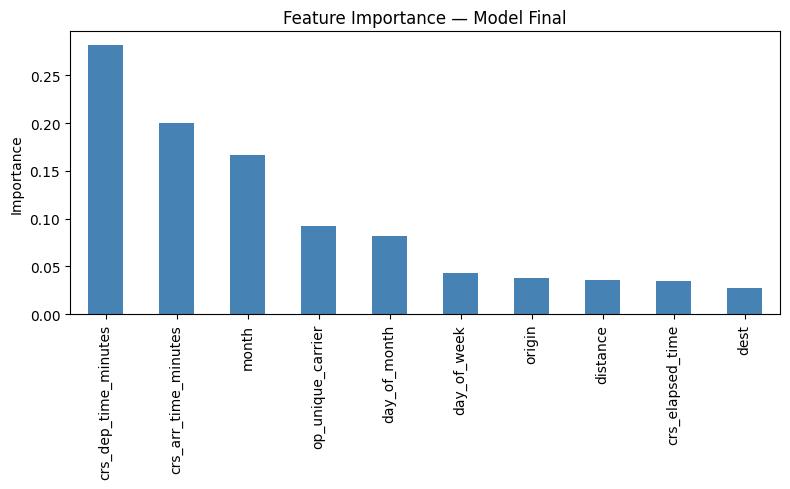

In [ ]:
# ============================================================
# MODELING — Step 5: Train Model Final (seluruh data)
# ============================================================
import gc

print("Training model final dengan seluruh data...")
print(f"class 0: {(y==0).sum():,} | class 1: {(y==1).sum():,}")

model_final = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    min_samples_leaf=10,
    class_weight='balanced',
    n_jobs=-1,
    random_state=42
)
model_final.fit(X, y)
gc.collect()
print("Model final selesai.")

# Feature importance
import pandas as pd
import matplotlib.pyplot as plt

feat_imp = pd.Series(model_final.feature_importances_, index=FEATURES).sort_values(ascending=False)
plt.figure(figsize=(8, 5))
feat_imp.plot(kind="bar", color="steelblue")
plt.title("Feature Importance — Model Final")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# MODELING — Step 6: Simpan Model & Encoder
# ============================================================
import joblib

joblib.dump(model_final, "model_flight_delay.pkl")
joblib.dump(encoders,    "encoders_flight_delay.pkl")

print("Tersimpan: model_flight_delay.pkl")
print("Tersimpan: encoders_flight_delay.pkl")

Tersimpan: model_flight_delay.pkl
Tersimpan: encoders_flight_delay.pkl


In [ ]:
# ============================================================
# MODELING — Step 7: Prediksi Data Penerbangan Baru
# ============================================================

def predict_delay(month, day_of_month, day_of_week,
                  carrier, origin, dest,
                  crs_dep_time_hhmm, crs_arr_time_hhmm,
                  crs_elapsed_time, distance):
    """
    Prediksi delay penerbangan.
    Waktu diinput format HHMM integer, misal 1430 = jam 14:30.
    """
    dep_min     = (crs_dep_time_hhmm // 100) * 60 + (crs_dep_time_hhmm % 100)
    arr_min     = (crs_arr_time_hhmm // 100) * 60 + (crs_arr_time_hhmm % 100)
    carrier_enc = encoders["op_unique_carrier"].transform([carrier])[0]
    origin_enc  = encoders["origin"].transform([origin])[0]
    dest_enc    = encoders["dest"].transform([dest])[0]

    features = np.array([[
        month, day_of_month, day_of_week,
        carrier_enc, origin_enc, dest_enc,
        dep_min, arr_min, crs_elapsed_time, distance
    ]])

    pred  = model_final.predict(features)[0]
    proba = model_final.predict_proba(features)[0][1]
    label = "DELAY (>15 menit)" if pred == 1 else "ON TIME"

    print(f"Hasil prediksi     : {label}")
    print(f"Probabilitas delay : {proba:.2%}")
    return pred, proba

# Contoh
predict_delay(
    month=6, day_of_month=16, day_of_week=1,
    carrier="AA", origin="LAX", dest="JFK",
    crs_dep_time_hhmm=800,
    crs_arr_time_hhmm=1620,
    crs_elapsed_time=340,
    distance=2475
)

Hasil prediksi     : ON TIME
Probabilitas delay : 33.86%


(np.int64(0), np.float64(0.338634912704274))